# Timbiriche con Minimax
---

### Cómo ver el tablero
- Rayas azules = Jugador 1, rayas rojas = Jugador 2
- Las rayas disponibles muestran una etiqueta (como `h01` = horizontal fila 0 col 1)
- Los cuadros completados muestran cuál jugador lo cerró

### Cómo ingresar un movimiento para modo H vs M
```
h 0 1   ->  raya horizontal, fila 0, columna 1
v 2 0   ->  raya vertical, fila 2, columna 0
ayuda   ->  ver todas las rayas disponibles
salir   ->  terminar
```

## Celda 1 — Todo el código del algoritmo
Primero se ejecuta esto:

In [1]:
import copy
import math
import time

# -------------------------------------------------------
# Representacion del tablero
#
# Se usan 3 listas de listas para guardar el estado:
#   rayas_h[f][c] = el que puso la raya horizontal (0=nadie, 1=J1, 2=J2)
#   rayas_v[f][c] = el que puso la raya vertical
#   cajas[f][c] = el que cerro la caja (0=abierta)
#
# Para un tablero de n cajas por lado:
#   rayas_h tiene n+1 filas y n columnas
#   rayas_v tiene n filas y n+1 columnas
# -------------------------------------------------------

class Tablero:

    def __init__(self, n=3):
        self.n = n
        self.rayas_h = [[0] * n for _ in range(n + 1)]
        self.rayas_v = [[0] * (n + 1) for _ in range(n)]
        self.cajas = [[0] * n for _ in range(n)]
        self.puntos = [0, 0]  # puntos[0] = J1, puntos[1] = J2
        self.turno = 1

    def copiar(self):
        return copy.deepcopy(self)

    def movimientos_posibles(self):
        # retorna todas las rayas que todavia no fueron puestas
        lista = []
        for f in range(self.n + 1):
            for c in range(self.n):
                if self.rayas_h[f][c] == 0:
                    lista.append(('h', f, c))
        for f in range(self.n):
            for c in range(self.n + 1):
                if self.rayas_v[f][c] == 0:
                    lista.append(('v', f, c))
        return lista

    def hacer_movimiento(self, mov):
        # aplica el movimiento en una copia y la retorna y el tablero original no cambia
        nuevo = self.copiar()
        tipo, f, c = mov

        if tipo == 'h':
            nuevo.rayas_h[f][c] = self.turno
        else:
            nuevo.rayas_v[f][c] = self.turno

        ###### revisar si se cerro alguna caja con esta raya ###########
        cajas_cerradas = 0

        # una raya horizontal toca la caja de abajo (f,c) y la de arriba (f-1,c)
        # una raya vertical toca la caja a la derecha (f,c) y a la izquierda (f,c-1)
        if tipo == 'h':
            candidatos = [(f, c), (f - 1, c)]
        else:
            candidatos = [(f, c), (f, c - 1)]

        for bf, bc in candidatos:
            if 0 <= bf < self.n and 0 <= bc < self.n:
                if nuevo.cajas[bf][bc] == 0 and nuevo._esta_completa(bf, bc):
                    nuevo.cajas[bf][bc] = self.turno
                    cajas_cerradas += 1

        nuevo.puntos[self.turno - 1] += cajas_cerradas

        # si no cerró caja le toca al otro jugador si cerro al menos una, el mismo jugador vuelve a jugar
        if cajas_cerradas == 0:
            nuevo.turno = 2 if self.turno == 1 else 1

        return nuevo, cajas_cerradas

    def _esta_completa(self, f, c):
        # una caja esta completa con los 4 lados
        top    = self.rayas_h[f][c]
        bottom = self.rayas_h[f + 1][c]
        left   = self.rayas_v[f][c]
        right  = self.rayas_v[f][c + 1]
        return top and bottom and left and right

    def contar_lados(self, f, c):
        top    = 1 if self.rayas_h[f][c] else 0
        bottom = 1 if self.rayas_h[f + 1][c] else 0
        left   = 1 if self.rayas_v[f][c] else 0
        right  = 1 if self.rayas_v[f][c + 1] else 0
        return top + bottom + left + right

    def juego_terminado(self):
        # todas las cajas cerradas = fin del juego
        for f in range(self.n):
            for c in range(self.n):
                if self.cajas[f][c] == 0:
                    return False
        return True

    def quien_gano(self):
        if self.puntos[0] > self.puntos[1]:
            return 1
        elif self.puntos[1] > self.puntos[0]:
            return 2
        else:
            return 0


# -------------------------------------------------------
# Visualizacion del tablero
# -------------------------------------------------------

# codigos de color ANSI
RESET  = '\033[0m'
AZUL   = '\033[94m'
ROJO   = '\033[91m'
VERDE  = '\033[92m'
GRIS   = '\033[90m'
AMARILLO = '\033[93m'

def mostrar_tablero(t, ultimo=None):
    n = t.n
    filas = []

    for f in range(n + 1):
        # fila con rayas horizontales
        linea = '  '
        for c in range(n):
            quien = t.rayas_h[f][c]
            if quien == 0:
                linea += 'o' + GRIS + '-h' + str(f) + str(c) + '-' + RESET
            elif quien == 1:
                if ultimo == ('h', f, c):
                    linea += 'o' + VERDE + '-----' + RESET
                else:
                    linea += 'o' + AZUL + '-----' + RESET
            else:
                if ultimo == ('v', f, c):
                    linea += 'o' + VERDE + '=====' + RESET
                else:
                    linea += 'o' + ROJO + '=====' + RESET
        linea += 'o'
        filas.append(linea)

        # fila con rayas verticales y cajas
        if f < n:
            linea = '  '
            for c in range(n + 1):
                quien = t.rayas_v[f][c]
                if quien == 0:
                    linea += GRIS + ':' + RESET
                elif quien == 1:
                    if ultimo == ('v', f, c):
                        linea += VERDE + '|' + RESET
                    else:
                        linea += AZUL + '|' + RESET
                else:
                    if ultimo == ('v', f, c):
                        linea += VERDE + '|' + RESET
                    else:
                        linea += ROJO + '|' + RESET

                # interior de la caja
                if c < n:
                    dueno = t.cajas[f][c]
                    if dueno == 1:
                        linea += '\033[44m\033[97m' + '  1  ' + RESET
                    elif dueno == 2:
                        linea += '\033[41m\033[97m' + '  2  ' + RESET
                    else:
                        linea += '     '
            filas.append(linea)

    # mostrar puntaje
    filas.append('')
    estado = '  ' + AZUL + 'J1: ' + str(t.puntos[0]) + ' pts' + RESET
    estado += '   ' + ROJO + 'J2: ' + str(t.puntos[1]) + ' pts' + RESET
    if t.juego_terminado():
        g = t.quien_gano()
        if g == 0:
            estado += '   ' + AMARILLO + 'EMPATE' + RESET
        else:
            estado += '   ' + AMARILLO + 'Gano J' + str(g) + RESET
    else:
        if t.turno == 1:
            estado += '   Turno: ' + AZUL + 'J1' + RESET
        else:
            estado += '   Turno: ' + ROJO + 'J2' + RESET
    filas.append(estado)

    print('\n'.join(filas))


def mostrar_leyenda():
    print()
    print('  Leyenda:')
    print('    ' + AZUL + '-----' + RESET + '  raya J1')
    print('    ' + ROJO + '=====' + RESET + '  raya J2')
    print('    ' + GRIS + '-h01-' + RESET + '  raya disponible (codigo: h 0 1)')
    print('    ' + GRIS + ':' + RESET + '      raya vertical disponible')
    print()
    print('  Formato: h fila col  o  v fila col')
    print('  Ejemplo: h 0 1')
    print()


def mostrar_opciones(t):
    movs = t.movimientos_posibles()
    horiz = []
    verti = []
    for tipo, f, c in movs:
        if tipo == 'h':
            horiz.append('h ' + str(f) + ' ' + str(c))
        else:
            verti.append('v ' + str(f) + ' ' + str(c))
    print()
    print('  Rayas disponibles:')
    print('  Horizontales: ' + ', '.join(horiz))
    print('  Verticales:   ' + ', '.join(verti))
    print()


# -------------------------------------------------------
# Heurística
#
# Estima que tan buena es la posición para un jugador.
# Se toma en cuenta:
#   - diferencia de puntos (lo mas importante)
#   - cajas que se puede cerrar ahora (3 lados)
#   - cajas que puede cerrar el rival ahora
#   - cajas con 2 lados (peligrosas)
# -------------------------------------------------------

def evaluar(t, jugador):
    rival = 2 if jugador == 1 else 1

    mis_puntos    = t.puntos[jugador - 1]
    puntos_rival  = t.puntos[rival - 1]
    diferencia    = (mis_puntos - puntos_rival) * 3

    cierro_yo  = 0
    cierra_el  = 0
    peligrosas = 0

    for f in range(t.n):
        for c in range(t.n):
            if t.cajas[f][c] != 0:
                continue
            lados = t.contar_lados(f, c)
            if lados == 3:
                if t.turno == jugador:
                    cierro_yo += 1
                else:
                    cierra_el += 1
            elif lados == 2:
                peligrosas += 1

    valor = diferencia + cierro_yo * 2 - cierra_el * 2 - peligrosas * 0.5
    return valor


# -------------------------------------------------------
# Minimax con poda alpha-beta
# -------------------------------------------------------

nodos = 0  # cuantos nodos se visitan

def minimax(t, profundidad, alpha, beta, jugador_max):
    global nodos
    nodos += 1

    # retornar el resultado real
    if t.juego_terminado():
        diff = t.puntos[jugador_max - 1] - t.puntos[2 - jugador_max]
        return diff * 100

    # limite de busqueda = usar la heuristica
    if profundidad == 0:
        return evaluar(t, jugador_max)

    movs = t.movimientos_posibles()

    if t.turno == jugador_max:
        # turno de MAX:
        mejor = -math.inf
        for mov in movs:
            hijo, _ = t.hacer_movimiento(mov)
            val = minimax(hijo, profundidad - 1, alpha, beta, jugador_max)
            if val > mejor:
                mejor = val
            if mejor > alpha:
                alpha = mejor
            if alpha >= beta:
                break  # poda
        return mejor
    else:
        # turno de MIN:
        mejor = math.inf
        for mov in movs:
            hijo, _ = t.hacer_movimiento(mov)
            val = minimax(hijo, profundidad - 1, alpha, beta, jugador_max)
            if val < mejor:
                mejor = val
            if mejor < beta:
                beta = mejor
            if alpha >= beta:
                break  # poda
        return mejor


def elegir_movimiento(t, profundidad=5):
    global nodos
    nodos = 0

    jugador = t.turno
    mejor_mov = None
    mejor_val = -math.inf

    inicio = time.time()
    for mov in t.movimientos_posibles():
        hijo, _ = t.hacer_movimiento(mov)
        val = minimax(hijo, profundidad - 1, -math.inf, math.inf, jugador)
        if val > mejor_val:
            mejor_val = val
            mejor_mov = mov
    fin = time.time()

    return mejor_mov, mejor_val, fin - inicio, nodos


# -------------------------------------------------------
# Leer el movimiento del input
# -------------------------------------------------------

def leer_jugada(texto, t):
    texto = texto.strip().lower()
    texto = texto.replace(',', ' ')
    partes = texto.split()

    if len(partes) == 3:
        tipo = partes[0]
        try:
            f = int(partes[1])
            c = int(partes[2])
        except:
            return None
    elif len(partes) == 1 and len(texto) >= 3:
        tipo = texto[0]
        try:
            f = int(texto[1])
            c = int(texto[2])
        except:
            return None
    else:
        return None

    if tipo != 'h' and tipo != 'v':
        return None

    mov = (tipo, f, c)
    if mov in t.movimientos_posibles():
        return mov
    return None


# -------------------------------------------------------
# Modo 1: Humano vs Maquina (extra)
# -------------------------------------------------------

def humano_vs_maquina(n=3, profundidad_ia=5, ia_juega_como=2):
    humano = 1 if ia_juega_como == 2 else 2
    t = Tablero(n)

    registro = []
    tiempos_ia = []
    nodos_ia = []

    print()
    print('=' * 50)
    print('  TIMBIRICHE - Humano vs Máquina')
    print('  Tablero ' + str(n) + 'x' + str(n))
    print('  Eres Jugador ' + str(humano))
    print('  IA es el Jugador ' + str(ia_juega_como))
    print('=' * 50)
    mostrar_leyenda()

    ultimo = None

    while not t.juego_terminado():
        print()
        mostrar_tablero(t, ultimo)
        print()

        if t.turno == ia_juega_como:
            print('  IA pensando...')
            mov, val, tiempo, n_nodos = elegir_movimiento(t, profundidad_ia)
            tiempos_ia.append(tiempo)
            nodos_ia.append(n_nodos)

            tipo, f, c = mov
            print('  IA juega: ' + tipo + ' ' + str(f) + ' ' + str(c))
            print('  (' + str(round(tiempo, 2)) + 's, ' + str(n_nodos) + ' nodos)')

            t, cerradas = t.hacer_movimiento(mov)
            ultimo = mov
            registro.append((ia_juega_como, mov, cerradas))
            if cerradas > 0:
                print('  La IA cerró ' + str(cerradas) + ' caja(s). Vuelva a jugar.')

        else:
            mostrar_opciones(t)
            while True:
                try:
                    entrada = input('  Tu jugada (J' + str(humano) + '): ')
                except EOFError:
                    entrada = 'salir'

                if entrada.lower() == 'salir':
                    print('  Partida terminada.')
                    return t, registro, tiempos_ia, nodos_ia

                if entrada.lower() == 'ayuda':
                    mostrar_opciones(t)
                    continue

                mov = leer_jugada(entrada, t)
                if mov is None:
                    print('  Movimiento invalido. Escribe ayuda para ver las opciones.')
                    continue

                t, cerradas = t.hacer_movimiento(mov)
                ultimo = mov
                registro.append((humano, mov, cerradas))
                if cerradas > 0:
                    print('  Cerrastes ' + str(cerradas) + ' caja(s). Vuelva a jugar.')
                break

    print()
    mostrar_tablero(t, ultimo)
    mostrar_resultado(t, humano, ia_juega_como)
    return t, registro, tiempos_ia, nodos_ia


# -------------------------------------------------------
# Modo 2: Maquina vs Maquina
# -------------------------------------------------------

def maquina_vs_maquina(n=3, prof_j1=5, prof_j2=5, pausa=0.5):
    from IPython.display import clear_output

    t = Tablero(n)
    registro = []
    tiempos = {1: [], 2: []}
    nodos_por_turno = {1: [], 2: []}
    profundidades = {1: prof_j1, 2: prof_j2}

    print()
    print('=' * 50)
    print('  TIMBIRICHE - Máquina vs Máquina')
    print('  Tablero ' + str(n) + 'x' + str(n))
    print('  J1 profundidad=' + str(prof_j1) + '  J2 profundidad=' + str(prof_j2))
    print('=' * 50)

    num_turno = 0
    ultimo = None

    while not t.juego_terminado():
        num_turno += 1
        j = t.turno
        prof = profundidades[j]

        clear_output(wait=True)
        print('\n  Turno ' + str(num_turno) + ' - J' + str(j) + ' pensando...\n')
        mostrar_tablero(t, ultimo)

        mov, val, tiempo, n_nodos = elegir_movimiento(t, prof)
        tiempos[j].append(tiempo)
        nodos_por_turno[j].append(n_nodos)

        tipo, f, c = mov
        print('\n  J' + str(j) + ' juega: ' + tipo + ' ' + str(f) + ' ' + str(c))
        print('  valor=' + str(round(val, 1)) + '  tiempo=' + str(round(tiempo, 2)) + 's  nodos=' + str(n_nodos))

        t, cerradas = t.hacer_movimiento(mov)
        ultimo = mov
        registro.append((j, mov, cerradas))

        if cerradas > 0:
            print('  J' + str(j) + ' cerró ' + str(cerradas) + ' caja(s). Vuelve a jugar.')

        if pausa > 0:
            time.sleep(pausa)

    clear_output(wait=True)
    print()
    mostrar_tablero(t, ultimo)
    mostrar_resultado(t)

    print()
    print('  Estadísticas:')
    for j in [1, 2]:
        if len(tiempos[j]) > 0:
            total = sum(tiempos[j])
            prom  = total / len(tiempos[j])
            tot_nodos = sum(nodos_por_turno[j])
            print('  J' + str(j) + ': ' + str(round(total, 2)) + 's total, '
                  + str(round(prom, 3)) + 's promedio, '
                  + str(tot_nodos) + ' nodos')

    return t, registro, tiempos, nodos_por_turno


def mostrar_resultado(t, humano=None, ia=None):
    print()
    print('=' * 50)
    print('  RESULTADO FINAL')
    print('  J1: ' + str(t.puntos[0]) + ' cajas')
    print('  J2: ' + str(t.puntos[1]) + ' cajas')
    g = t.quien_gano()
    if g == 0:
        print('  ' + AMARILLO + 'EMPATE' + RESET)
    elif humano is not None and g == humano:
        print('  ' + AMARILLO + 'Ganaste! (J' + str(g) + ')' + RESET)
    elif ia is not None and g == ia:
        print('  ' + AMARILLO + 'Gano la IA (J' + str(g) + ')' + RESET)
    else:
        print('  ' + AMARILLO + 'Gano J' + str(g) + RESET)
    print('=' * 50)


# -------------------------------------------------------
# Pruebas
# -------------------------------------------------------

def correr_pruebas():
    errores = 0

    print('\n' + '-' * 45)
    print('  Pruebas')
    print('-' * 45)

    # prueba 1: tablero 2x2 vacio tiene 12 rayas disponibles
    t = Tablero(2)
    if len(t.movimientos_posibles()) == 12:
        print('  OK tablero 2x2: 12 movimientos iniciales')
    else:
        print('  FALLO tablero 2x2: ' + str(len(t.movimientos_posibles())) + ' movimientos (esperaba 12)')
        errores += 1

    # prueba 2: despues de poner una raya quedan 11
    t2, _ = t.hacer_movimiento(('h', 0, 0))
    if len(t2.movimientos_posibles()) == 11:
        print('  OK despues de un movimiento quedan 11')
    else:
        print('  FALLO deberían quedar 11')
        errores += 1

    # prueba 3: el tablero original no debe cambiar
    if t.rayas_h[0][0] == 0:
        print('  OK el original no cambia al copiar')
    else:
        print('  FALLO el original cambio')
        errores += 1

    # prueba 4: cerrar una caja
    # J1 pone h0,0 -> turno pasa a J2
    # J2 pone h1,0 -> turno pasa a J1
    # J1 pone v0,0 -> turno pasa a J2
    # J2 pone v0,1 -> cierra la caja, J2 vuelve a jugar
    t = Tablero(2)
    t, _ = t.hacer_movimiento(('h', 0, 0))
    t, _ = t.hacer_movimiento(('h', 1, 0))
    t, _ = t.hacer_movimiento(('v', 0, 0))
    t, cerradas = t.hacer_movimiento(('v', 0, 1))
    if cerradas == 1 and t.puntos[1] == 1 and t.cajas[0][0] == 2:
        print('  OK cerrar caja: punto a J2')
    else:
        print('  FALLO cerrar caja no funciona bien')
        errores += 1

    # prueba 5: el turno no cambia cuando se cierra una caja
    if t.turno == 2:
        print('  OK turno no cambia al cerrar caja')
    else:
        print('  FALLO ')
        errores += 1

    # prueba 6: detectar fin del juego
    t = Tablero(2)
    while not t.juego_terminado():
        movs = t.movimientos_posibles()
        t, _ = t.hacer_movimiento(movs[0])
    if t.juego_terminado() and sum(t.puntos) == 4:
        print('  Fin del juego detectado, 4 puntos en total')
    else:
        print('  FALLO no se detectó el fin del juego')
        errores += 1

    # prueba 7: minimax tiene que elegir cerrar la caja obvia
    # ponemos 3 lados de la caja (0,0), el cuarto lado es v(0,1)
    t = Tablero(2)
    t.rayas_h[0][0] = 1
    t.rayas_h[1][0] = 1
    t.rayas_v[0][0] = 1
    t.turno = 1
    mov, _, _, _ = elegir_movimiento(t, 3)
    if mov == ('v', 0, 1):
        print('  OK minimax elige cerrar la caja (v 0 1)')
    else:
        print('  FALLO minimax eligió ' + str(mov) + ' en vez de v 0 1')
        errores += 1

    print('-' * 45)
    if errores == 0:
        print('  Todas las pruebas pasaron')
    else:
        print('  ' + str(errores) + ' pruebas fallaron')
    print('-' * 45)


# -------------------------------------------------------
# Mostrar el camino de la partida
# -------------------------------------------------------

def mostrar_camino(registro, n, cada_cuantos=5):
    print()
    print('=' * 50)
    print('  Camino de la partida')
    print('=' * 50)

    t = Tablero(n)
    print('\n  Estado inicial:')
    mostrar_tablero(t)

    for i in range(len(registro)):
        jugador, mov, cerradas = registro[i]
        tipo, f, c = mov
        t, _ = t.hacer_movimiento(mov)

        if tipo == 'h':
            dir_str = 'horizontal'
        else:
            dir_str = 'vertical'

        print('\n  Mov ' + str(i + 1) + ': J' + str(jugador) + ' pone raya ' + dir_str + ' (' + tipo + ' ' + str(f) + ' ' + str(c) + ')', end='')
        if cerradas > 0:
            print(' -> cerro ' + str(cerradas) + ' caja(s)', end='')
        print()
        print('  J1=' + str(t.puntos[0]) + '  J2=' + str(t.puntos[1]))

        # muestra cada ciertos movimientos o cuando se cierra una caja
        if cada_cuantos > 0 and (i + 1) % cada_cuantos == 0:
            mostrar_tablero(t, mov)
        elif cerradas > 0:
            mostrar_tablero(t, mov)

    print()
    print('  Estado final:')
    mostrar_tablero(t)
    g = t.quien_gano()
    print('\n  Total de movimientos: ' + str(len(registro)))
    if g == 0:
        print('  Resultado: empate')
    else:
        print('  Resultado: gano J' + str(g))
    print('=' * 50)


# -------------------------------------------------------
# Tiempo de ejecucion
# -------------------------------------------------------

def mostrar_tiempos(registro, tiempos=None, nodos_lista=None, tiempos_mvm=None, nodos_mvm=None):
    print()
    print('-' * 45)
    print('  Tiempo de ejecucion del algoritmo')
    print('-' * 45)
    print('  Total de movimientos: ' + str(len(registro)))

    # para m vs m
    if tiempos_mvm is not None:
        for j in [1, 2]:
            ts = tiempos_mvm[j]
            ns = nodos_mvm[j]
            if len(ts) > 0:
                print()
                print('  J' + str(j) + ':')
                print('    Turnos:   ' + str(len(ts)))
                print('    Total:    ' + str(round(sum(ts), 3)) + ' s')
                print('    Promedio: ' + str(round(sum(ts) / len(ts), 4)) + ' s')
                print('    Maximo:   ' + str(round(max(ts), 4)) + ' s')
                print('    Nodos:    ' + str(sum(ns)) + ' total')

    # para h vs m
    if tiempos is not None and len(tiempos) > 0:
        print()
        print('  IA:')
        print('    Turnos:   ' + str(len(tiempos)))
        print('    Total:    ' + str(round(sum(tiempos), 3)) + ' s')
        print('    Promedio: ' + str(round(sum(tiempos) / len(tiempos), 4)) + ' s')
        print('    Maximo:   ' + str(round(max(tiempos), 4)) + ' s')
        if nodos_lista is not None:
            print('    Nodos:    ' + str(sum(nodos_lista)) + ' total')

    print('-' * 45)


# -------------------------------------------------------
# Graficas con matplotlib
# -------------------------------------------------------

def graficar_partida(registro, tiempos_mvm=None, nodos_mvm=None, tiempos_ia=None, nodos_ia=None, titulo='Timbiriche'):
    import matplotlib.pyplot as plt

    # evolución del marcador
    p1 = [0]
    p2 = [0]
    for jugador, mov, cerradas in registro:
        if jugador == 1:
            p1.append(p1[-1] + cerradas)
            p2.append(p2[-1])
        else:
            p1.append(p1[-1])
            p2.append(p2[-1] + cerradas)

    if tiempos_mvm is not None:
        # gráficas para maquina vs maquina
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(titulo)

        # tiempo por turno
        ts1 = tiempos_mvm[1]
        ts2 = tiempos_mvm[2]
        xs1 = [i for i, (j, _, _) in enumerate(registro) if j == 1]
        xs2 = [i for i, (j, _, _) in enumerate(registro) if j == 2]
        axes[0].bar(xs1, ts1, color='#4A90D9', label='J1')
        axes[0].bar(xs2, ts2, color='#E05A5A', label='J2')
        axes[0].set_title('Tiempo por turno')
        axes[0].set_xlabel('Turno')
        axes[0].set_ylabel('Segundos')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)

        # nodos por turno
        ns1 = nodos_mvm[1]
        ns2 = nodos_mvm[2]
        axes[1].plot(xs1, ns1, 'o-', color='#4A90D9', label='J1')
        axes[1].plot(xs2, ns2, 's-', color='#E05A5A', label='J2')
        axes[1].set_title('Nodos explorados por turno')
        axes[1].set_xlabel('Turno')
        axes[1].set_ylabel('Nodos')
        axes[1].set_yscale('log')
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        # marcador
        axes[2].step(range(len(p1)), p1, where='post', color='#4A90D9', label='J1', linewidth=2)
        axes[2].step(range(len(p2)), p2, where='post', color='#E05A5A', label='J2', linewidth=2)
        axes[2].set_title('Evolucion del marcador')
        axes[2].set_xlabel('Movimiento')
        axes[2].set_ylabel('Cajas')
        axes[2].legend()
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    elif tiempos_ia is not None:
        # gráficas para h vs m
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(titulo)

        # tiempo por turno de la ia
        axes[0].bar(range(len(tiempos_ia)), tiempos_ia, color='#E05A5A')
        if len(tiempos_ia) > 0:
            prom = sum(tiempos_ia) / len(tiempos_ia)
            axes[0].axhline(prom, color='black', linestyle='--', label='promedio ' + str(round(prom, 3)) + 's')
            axes[0].legend()
        axes[0].set_title('Tiempo por turno (IA)')
        axes[0].set_xlabel('Turno de la IA')
        axes[0].set_ylabel('Segundos')
        axes[0].grid(axis='y', alpha=0.3)

        # nodos
        if nodos_ia is not None:
            axes[1].plot(range(len(nodos_ia)), nodos_ia, 'o-', color='#9B59B6')
            axes[1].set_title('Nodos explorados (IA)')
            axes[1].set_xlabel('Turno')
            axes[1].set_ylabel('Nodos')
            axes[1].set_yscale('log')
            axes[1].grid(alpha=0.3)

        # marcador
        axes[2].step(range(len(p1)), p1, where='post', color='#4A90D9', label='J1', linewidth=2)
        axes[2].step(range(len(p2)), p2, where='post', color='#E05A5A', label='J2', linewidth=2)
        axes[2].set_title('Evolución del marcador')
        axes[2].set_xlabel('Movimiento')
        axes[2].set_ylabel('Cajas')
        axes[2].legend()
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


print('Listo')


Listo


## Celda 2 — Pruebas
Verifica que la implementación esté bien:

In [2]:
correr_pruebas()


---------------------------------------------
  Pruebas
---------------------------------------------
  OK tablero 2x2: 12 movimientos iniciales
  OK despues de un movimiento quedan 11
  OK el original no cambia al copiar
  OK cerrar caja: punto a J2
  OK turno no cambia al cerrar caja
  Fin del juego detectado, 4 puntos en total
  OK minimax elige cerrar la caja (v 0 1)
---------------------------------------------
  Todas las pruebas pasaron
---------------------------------------------


## Celda 3 — Maquina vs Maquina
Dos agentes Minimax juegan en contra. `N` es la cantidad de cajas por lado (N=3 es 3x3 cajas).

In [3]:
N      = 3
PROF1  = 5
PROF2  = 5
PAUSA  = 0.5  # segundos entre movimientos

t_final, reg, tiempos_mvm, nodos_mvm = maquina_vs_maquina(
    n=N, prof_j1=PROF1, prof_j2=PROF2, pausa=PAUSA
)


  o-----o-----o=====o
  |  2  |  2  |  2  |
  o-----o-----o=====o
  |  2  |  2  |  2  |
  o-----o=====o-----o
  |  1  |  2  |  2  |
  o=====o=====o=====o

  J1: 1 pts   J2: 8 pts   Gano J2

  RESULTADO FINAL
  J1: 1 cajas
  J2: 8 cajas
  Gano J2

  Estadísticas:
  J1: 21.06s total, 2.34s promedio, 519596 nodos
  J2: 19.45s total, 1.297s promedio, 480522 nodos


### Tiempo de ejecucion

In [4]:
mostrar_tiempos(reg, tiempos_mvm=tiempos_mvm, nodos_mvm=nodos_mvm)


---------------------------------------------
  Tiempo de ejecucion del algoritmo
---------------------------------------------
  Total de movimientos: 24

  J1:
    Turnos:   9
    Total:    21.062 s
    Promedio: 2.3402 s
    Maximo:   5.156 s
    Nodos:    519596 total

  J2:
    Turnos:   15
    Total:    19.448 s
    Promedio: 1.2965 s
    Maximo:   4.291 s
    Nodos:    480522 total
---------------------------------------------


### Camino de la partida
Muestra el tablero cada 1 movimiento (es custom) y siempre que se cierra una caja.

In [6]:
mostrar_camino(reg, n=N, cada_cuantos=1)


  Camino de la partida

  Estado inicial:
  o-h00-o-h01-o-h02-o
  :     :     :     :
  o-h10-o-h11-o-h12-o
  :     :     :     :
  o-h20-o-h21-o-h22-o
  :     :     :     :
  o-h30-o-h31-o-h32-o

  J1: 0 pts   J2: 0 pts   Turno: J1

  Mov 1: J1 pone raya horizontal (h 0 0)
  J1=0  J2=0
  o-----o-h01-o-h02-o
  :     :     :     :
  o-h10-o-h11-o-h12-o
  :     :     :     :
  o-h20-o-h21-o-h22-o
  :     :     :     :
  o-h30-o-h31-o-h32-o

  J1: 0 pts   J2: 0 pts   Turno: J2

  Mov 2: J2 pone raya horizontal (h 3 1)
  J1=0  J2=0
  o-----o-h01-o-h02-o
  :     :     :     :
  o-h10-o-h11-o-h12-o
  :     :     :     :
  o-h20-o-h21-o-h22-o
  :     :     :     :
  o-h30-o=====o-h32-o

  J1: 0 pts   J2: 0 pts   Turno: J1

  Mov 3: J1 pone raya horizontal (h 0 1)
  J1=0  J2=0
  o-----o-----o-h02-o
  :     :     :     :
  o-h10-o-h11-o-h12-o
  :     :     :     :
  o-h20-o-h21-o-h22-o
  :     :     :     :
  o-h30-o=====o-h32-o

  J1: 0 pts   J2: 0 pts   Turno: J2

  Mov 4: J2 pone raya horiz

### Graficas

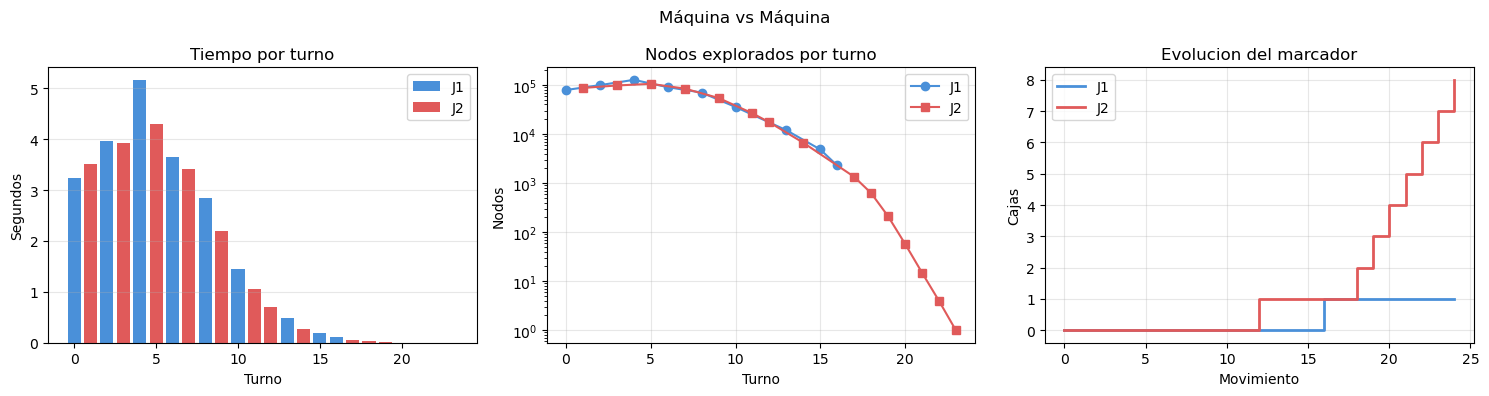

In [7]:
graficar_partida(reg, tiempos_mvm=tiempos_mvm, nodos_mvm=nodos_mvm, titulo='Máquina vs Máquina')

## Celda 4 — Humano vs Maquina
Juegar contra la IA del juego. Se siguen las instrucciones de arriba:

In [7]:
N          = 3
PROF_IA    = 5
IA_JUGADOR = 2  # IA

t_hvm, reg_hvm, tiempos_ia, nodos_ia = humano_vs_maquina(
    n=N, profundidad_ia=PROF_IA, ia_juega_como=IA_JUGADOR
)


,==================================================
,  TIMBIRICHE - Humano vs Maquina
,  Tablero 3x3
,  Eres el Jugador 1
,  IA es el Jugador 2
,==================================================
,
,  Leyenda:
,    -----  raya J1
,    =====  raya J2
,    -h01-  raya disponible (codigo: h 0 1)
,    :      raya vertical disponible
,
,  Formato: h fila col  o  v fila col
,  Ejemplo: h 0 1
,
,
,  o-h00-o-h01-o-h02-o
,  :     :     :     :
,  o-h10-o-h11-o-h12-o
,  :     :     :     :
,  o-h20-o-h21-o-h22-o
,  :     :     :     :
,  o-h30-o-h31-o-h32-o
,
,  J1: 0 pts   J2: 0 pts   Turno: J1
,
,
,  Rayas disponibles:
,  Horizontales: h 0 0, h 0 1, h 0 2, h 1 0, h 1 1, h 1 2, h 2 0, h 2 1, h 2 2, h 3 0, h 3 1, h 3 2
,  Verticales:   v 0 0, v 0 1, v 0 2, v 0 3, v 1 0, v 1 1, v 1 2, v 1 3, v 2 0, v 2 1, v 2 2, v 2 3
,
,  Tu jugada (J1): v 2 0
,
,  o-h00-o-h01-o-h02-o
,  :     :     :     :
,  o-h10-o-h11-o-h12-o
,  :     :     :     :
,  o-h20-o-h21-o-h22-o
,  |     :     :     :
,  o-h30-o-h3

### Tiempo de ejecucion

In [9]:
if reg_hvm:
    mostrar_tiempos(reg_hvm, tiempos=tiempos_ia, nodos_lista=nodos_ia)


,---------------------------------------------
,  Tiempo de ejecucion del algoritmo
,---------------------------------------------
,  Total de movimientos: 24
,
,  IA:
,    Turnos:   14
,    Total:    26.39 s
,    Promedio: 1.885 s
,    Maximo:   6.13 s
,    Nodos:    540020 total
,---------------------------------------------


### Camino de la partida

In [10]:
if reg_hvm:
    mostrar_camino(reg_hvm, n=N, cada_cuantos=1)


,==================================================
,  Camino de la partida
,==================================================
,
,  Estado inicial:
,  o-h00-o-h01-o-h02-o
,  :     :     :     :
,  o-h10-o-h11-o-h12-o
,  :     :     :     :
,  o-h20-o-h21-o-h22-o
,  :     :     :     :
,  o-h30-o-h31-o-h32-o
,
,  J1: 0 pts   J2: 0 pts   Turno: J1
,
,  Mov 1: J1 pone raya vertical (v 2 0)
,  J1=0  J2=0
,  o-h00-o-h01-o-h02-o
,  :     :     :     :
,  o-h10-o-h11-o-h12-o
,  :     :     :     :
,  o-h20-o-h21-o-h22-o
,  |     :     :     :
,  o-h30-o-h31-o-h32-o
,
,  J1: 0 pts   J2: 0 pts   Turno: J2
,
,  Mov 2: J2 pone raya horizontal (h 0 1)
,  J1=0  J2=0
,  o-h00-o=====o-h02-o
,  :     :     :     :
,  o-h10-o-h11-o-h12-o
,  :     :     :     :
,  o-h20-o-h21-o-h22-o
,  |     :     :     :
,  o-h30-o-h31-o-h32-o
,
,  J1: 0 pts   J2: 0 pts   Turno: J1
,
,  Mov 3: J1 pone raya horizontal (h 1 0)
,  J1=0  J2=0
,  o-h00-o=====o-h02-o
,  :     :     :     :
,  o-----o-h11-o-h12-o
,  :     

### Graficas

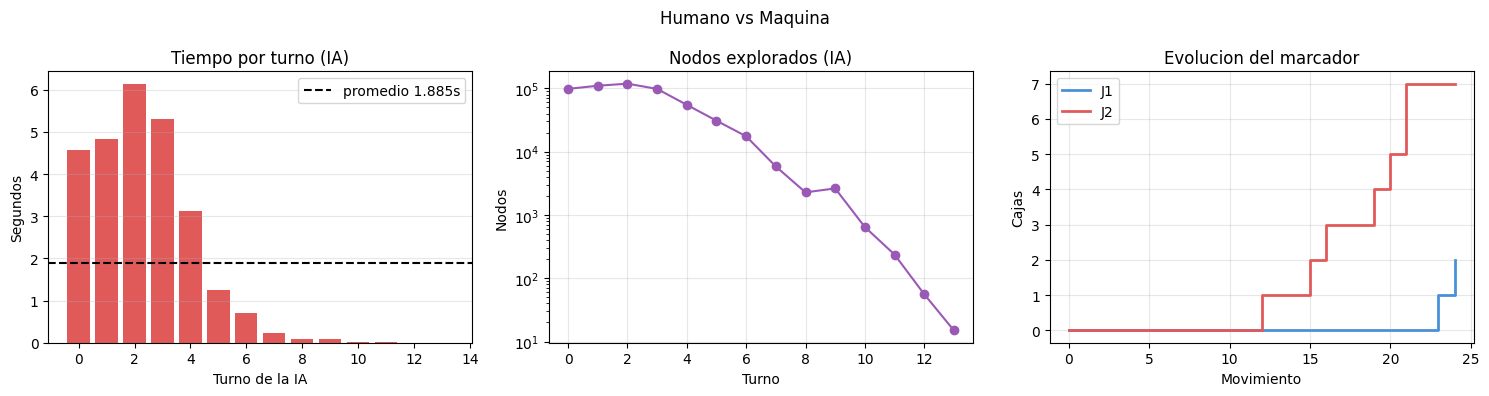

In [11]:
if reg_hvm and len(tiempos_ia) > 0:
    graficar_partida(reg_hvm, tiempos_ia=tiempos_ia, nodos_ia=nodos_ia,
                     titulo='Humano vs Máquina')

## Celda 5 — Benchmark
Mide como crece el tiempo con la profundidad.

Benchmark tablero 2x2
,  prof   tiempo        nodos
,  --------------------------------
,  1      0.0005        12
,  2      0.0047        144
,  3      0.0181        514
,  4      0.0615        2122
,  5      0.2535        8194
,  6      1.3122        42224
,  7      4.9455        161660


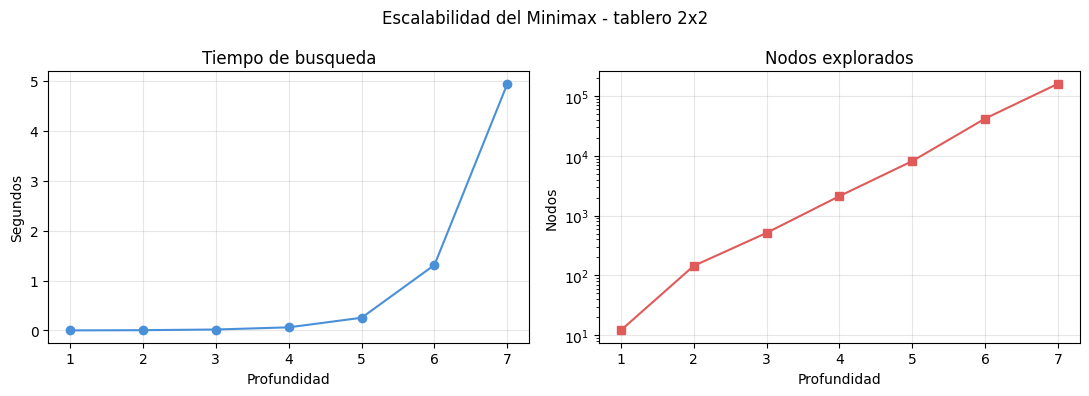

In [12]:
import matplotlib.pyplot as plt

def benchmark(n_tablero=2, profundidades=None):
    if profundidades is None:
        profundidades = [1, 2, 3, 4, 5, 6, 7]

    t = Tablero(n_tablero)
    lista_tiempos = []
    lista_nodos = []

    print('Benchmark tablero ' + str(n_tablero) + 'x' + str(n_tablero))
    print('  prof   tiempo        nodos')
    print('  ' + '-'*32)

    for p in profundidades:
        _, _, dur, n = elegir_movimiento(t, p)
        lista_tiempos.append(dur)
        lista_nodos.append(n)
        print('  ' + str(p) + '      ' + str(round(dur, 4)) + '        ' + str(n))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle('Escalabilidad del Minimax - tablero ' + str(n_tablero) + 'x' + str(n_tablero))

    ax1.plot(profundidades, lista_tiempos, 'o-', color='#4A90D9')
    ax1.set_title('Tiempo de busqueda')
    ax1.set_xlabel('Profundidad')
    ax1.set_ylabel('Segundos')
    ax1.grid(alpha=0.3)

    ax2.plot(profundidades, lista_nodos, 's-', color='#E05A5A')
    ax2.set_title('Nodos explorados')
    ax2.set_xlabel('Profundidad')
    ax2.set_ylabel('Nodos')
    ax2.set_yscale('log')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

benchmark(n_tablero=2, profundidades=[1, 2, 3, 4, 5, 6, 7])

## Celda 6 — Experimento: IA fuerte vs IA debil


,  o-----o=====o-----o
,  |  2  |  2  |  2  |
,  o-----o=====o=====o
,  |  2  |  2  |  2  |
,  o-----o=====o-----o
,  |  2  |  1  |  1  |
,  o-----o=====o=====o
,
,  J1: 2 pts   J2: 7 pts   Gano J2
,
,==================================================
,  RESULTADO FINAL
,  J1: 2 cajas
,  J2: 7 cajas
,  Gano J2
,==================================================
,
,  Estadisticas:
,  J1: 0.13s total, 0.013s promedio, 2565 nodos
,  J2: 23.89s total, 1.707s promedio, 526340 nodos


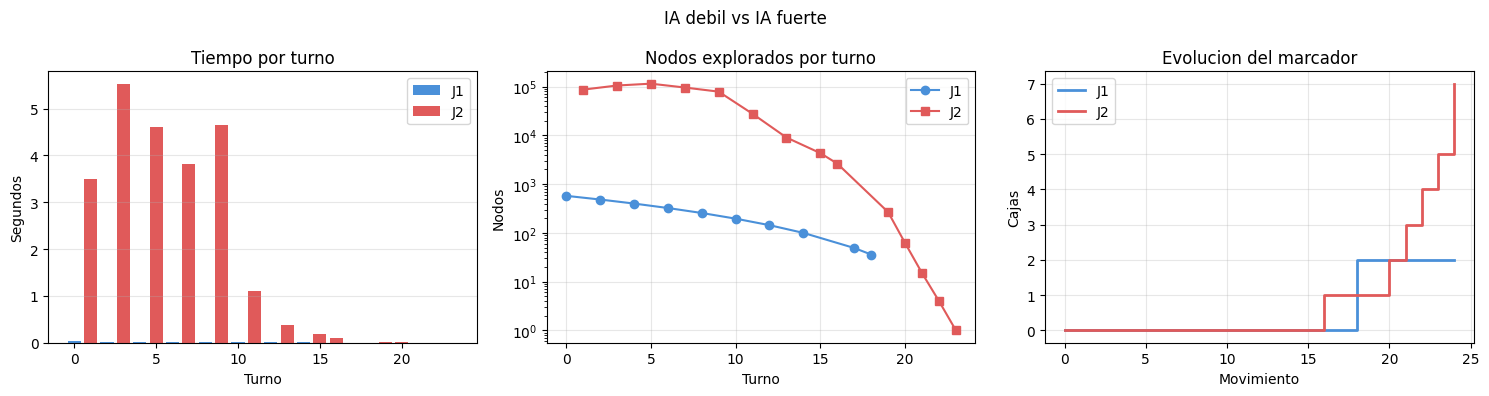

In [13]:
from IPython.display import clear_output

print('J1 (profundidad=2) vs J2 (profundidad=5)')
t_exp, reg_exp, t_exp_mvm, n_exp_mvm = maquina_vs_maquina(n=3, prof_j1=2, prof_j2=5, pausa=0.2)
graficar_partida(reg_exp, tiempos_mvm=t_exp_mvm, nodos_mvm=n_exp_mvm, titulo='IA débil vs IA fuerte')

---
## Informe

### Implementación

El programa implementa el juego Timbiriche (Lines and Boxes) con un agente basado en el algoritmo Minimax con poda Alpha-Beta, desarrollado en un cuaderno organizado en celdas separadas para mantener el código modular.

El estado del tablero se representa con tres listas de listas: `rayas_h[f][c]` para rayas horizontales, `rayas_v[f][c]` para rayas verticales y `cajas[f][c]` para registrar quién cerró cada caja (0 = abierta, 1 = J1, 2 = J2). La función `movimientos_posibles()` retorna todas las rayas con valor 0. La función `hacer_movimiento()` genera una copia completa del tablero con `copy.deepcopy` antes de aplicar el movimiento, de modo que el estado original nunca se modifica y el árbol de búsqueda puede explorar ramas de forma independiente. Si el movimiento cierra al menos una caja, el jugador mantiene su turnp, si no el turno pasa al otro. El estado objetivo se alcanza cuando todas las celdas de `cajas` son distintas de 0, verificado por `juego_terminado()`.

Se explora el árbol de juego recursivamente hasta una profundidad que es  configurable. En cada nodo se usa `t.turno` para saber si corresponde a MAX o MIN, en lugar de tratar de saberlo por la paridad de la profundidad como en el Minimax clásico, es lo mismo pero con esa variable. Se hizo así porque quien cierra una caja vuelve a jugar, por lo que el turno no siempre alterna entre niveles. Cuando se alcanza el límite de profundidad se llama a `evaluar()`; cuando el juego termina antes, se retorna la diferencia real de puntos multiplicada por 100. La poda Alpha-Beta descarta ramas que no pueden cambiar el resultado cuando `alpha >= beta`, lo que reduce (bastantes) nodos explorados sin afectar la calidad de la decisión.

Para el desarrollo se revisaron algunos repositorios públicos como punto de referencia:
- **github.com/Camm66/Dots-And-Boxes** — implementación en Python con CLI que usa Minimax con alpha-beta. Ayudó a entender cómo estructurar la lógica de cierre de cajas.
- **github.com/Armando8766/Dots-And-Boxes** — similar al anterior pero con tamaño de tablero configurable y selección de profundidad. Referencia para el manejo de parámetros.
- **github.com/OJP98/minimax-dots-and-boxes** — desarrollado para un curso de IA de la Universidad del Valle de Guatemala. Fue útil para ver cómo abordaron la función de evaluación heurística.

---

### Heurística utilizada

La función `evaluar()` estima qué tan buena es una posición para un jugador. Con cuatro factores:

| Factor | Peso |
|:-------|:----:|
| Diferencia de puntos (cajas propias menos las del rival) | ×3 |
| Cajas que el jugador puede cerrar en este turno (3 lados hechos) | +2 por caja |
| Cajas que el otro jugador puede cerrar en el próximo turno | −2 por caja |
| Cajas con exactamente 2 lados (peligrosas) | −0.5 por caja |

La lógica es que en el juego poner el tercer lado de una caja es casi siempre un error, porque se regala al otro jugador. La penalización por cajas con 2 lados prevee esa situación antes de que ocurra. La diferencia de puntos es ki que tiene peso al final porque es lo que define el ganador.

---

### Resultados obtenidos

Se ejecutaron cuatro pruebas. El modo Máquina vs Máquina es la primera prueba del algoritmo. El benchmark de escalabilidad también es otra cosa que pedía mostrar gráficas como tiempo de ejecución, aunque la forma de hacerki como medición por profundidad fue decisión propia. Los otros dos modos, Humano vs Máquina e IA débil vs IA fuerte, no estaban en el enunciado y se agregaron como experimentos para analizar el comportamiento del algoritmo desde distintos ángulos.

**Máquina vs Máquina (profundidad 5 vs 5, tablero 3×3):** los tiempos por turno arrancan entre 4 y 7 segundos al inicio cuando el árbol es más amplio, y bajan conforme hay menos movimientos disponibles. Los nodos explorados pasan de aprox 10**5 al inicio a menos de 10 al final. Se ve que ambos jugadores se mantienen sin puntos durante la mayor parte de la partida y el jugador 2 acumula la mayoría de cajas al final.

**Humano vs Máquina (profundidad 5, tablero 3×3) (extra):** el tiempo promedio de respuesta de la IA fue de 1.885 segundos por turno. El resultado fue 7 a 1 a favor de la IA, lo que muestra que con profundidad 5 el agente juega de forma efectiva contra un humano sin estrategia específica del juego. Aunque aquí hay que decir que hicimos las jugadas sin pensar más que todo para probar el algoritmo.

**Benchmark de escalabilidad (tablero 2×2, profundidades 1 a 7):**

| Profundidad | Tiempo (s) | Nodos |
|:-----------:|:----------:|:-----:|
| 1 | 0.0005 | 12 |
| 2 | 0.0047 | 144 |
| 3 | 0.0181 | 514 |
| 4 | 0.0615 | 2,122 |
| 5 | 0.2535 | 8,194 |
| 6 | 1.3122 | 42,224 |
| 7 | 4.9455 | 161,660 |

El crecimiento es exponencial, como dice la teoría del Minimax. La poda Alpha-Beta ayuda pero no elimina eso.

**IA débil vs IA fuerte (J1 profundidad 2 vs J2 profundidad 5) (extra):** J1 exploró 2,565 nodos con 0.013s promedio por turno. J2 exploró 526,340 nodos con 1.707s promedio. El resultado fue 7 a 2 a favor de J2, se confirma que a más profundidad se obtienen mejores decisiones.

---

### Decisiones de diseño y desafíos encontrados

Se usaron tres matrices para el tablero porque así se verifica el cierre de una caja usando cuatro posiciones por índice. Se usó `copy.deepcopy` para simplificar la lógica del árbol de búsqueda tal y como se hace en uno de los repositorios que encontramos de referencia, evitando tener que deshacer movimientos manualmente, pero esto tiene un costo en memoria. La profundidad de búsqueda se dejó custom para elegir entre calidad y tiempo de juego.

El desafío más fuerte fue el manejo del turno en Minimax. Primero se intentó usar la paridad de la profundidad para determinar MAX y MIN pero producía decisiones incorrectas cuando un jugador cerraba varias cajas seguidas. Lo de  leer `t.turno` desde el estado fue lo mejor. Lo otro que se complicó fue el rendimiento: con tablero 3×3 y profundidad 5 los tiempos son manejables, pero con el benchmark se ve que escalar profundidades es inviable sin optimizaciones.